In [1]:
%load_ext autoreload
%autoreload 2

import pickle

import jax
import jaxopt
import jax.nn as jnn
import jax.numpy as jnp
import jax.scipy as jsp
from functools import partial

import time as tt
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 18

import os
import corner
import numpy as np
import multiprocessing as mp

from potentials import *
from integrants_with_binning import *
from ghMoments import *
from utils import *
from constants import EPSILON

from potentials import NFW_acceleration
from densities import MiyamotoNagai_density

from CylindricalSpline import get_phi_m, get_acc, evaluate_phi_axisymmetric

path = '/home/hz420/python_script/SchwarMAX/'

In [2]:
@jax.jit
def potential_func(x, y, z, dict_phi, params_halo):
    """ Returns Phi(R, z) """
    phi_halo = NFW_potential(x, y, z, params_halo)
    phi_disk = evaluate_phi_axisymmetric(x, y, z, dict_phi)
    return phi_halo + phi_disk

@jax.jit
def density_func(x, y, z, params):
    """ Returns Stellar Density nu(R, z) """
    # Double Exponential Disk
    val = MiyamotoNagai_density(x, y, z, params)
    return val

@jax.jit
def dPhi_dz(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t z
    d = 5e-3
    return (potential_func(x, y, z+d, dict_phi, params_halo) - potential_func(x, y, z-d, dict_phi, params_halo)) / (2*d)

@jax.jit
def dPhi_dR(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t R
    d = 5e-3
    R = jnp.sqrt(x**2 + y**2)
    return (potential_func(R+d, 0, z, dict_phi, params_halo) - potential_func(R-d, 0, z, dict_phi, params_halo)) / (2*d)

@jax.jit
def get_jeans_moments(x_star, y_star, z_star, dict_phi, params_disc, params_halo, anisotropy_b=1.0):
    """
    Computes (v_mean, sigma_R, sigma_z, sigma_phi) for a star at (R, z).
    
    Parameters:
    -----------
    x_star, y_star, z_star : float
        Coordinates of the particle.
    density_fn : function
        Function returning stellar density nu(R, z).
    anisotropy_b : float
        sigma_R^2 / sigma_z^2. Default 1.0 (isotropic).
    """
    R_star = jnp.sqrt(x_star**2 + y_star**2)
    
    # --- Step 1: Compute Sigma_z (Vertical Integration) ---
    
    # Integrand: nu(R, z) * dPhi/dz
    def integrand(z_prime):
        return density_func(x_star, y_star, z_prime, params_disc) * dPhi_dz(x_star, y_star, z_prime, dict_phi, params_halo)
    
    # Integrate from z_star to infinity (e.g., 20 kpc)
    # Note: We assume symmetry, so we integrate |z| to infinity
    pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
    dx = pts[1] - pts[0]
    # integrand_val = integrand(pts)
    integrand_val = jax.vmap(integrand, in_axes = (0))(pts)
    integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)
    
    nu_val = density_func(x_star, y_star, z_star, params_disc)
    # if nu_val <= 0: return 0, 0, 0, 0
    
    sigma_z2 = (1.0 / nu_val) * integral_val
    
    sigma_z2 = jnp.maximum(sigma_z2, 0.0)

    sigma_z = jnp.sqrt(sigma_z2)
    
    # --- Step 2: Compute Sigma_R (Anisotropy assumption) ---
    sigma_R2 = anisotropy_b * sigma_z2
    sigma_R = jnp.sqrt(sigma_R2)
    
    # --- Step 3: Compute v_phi_total^2 (Radial Equation) ---
    # We need d(nu * sigma_R^2) / dR
    # Since sigma_R^2 = b * sigma_z^2, we need d(b * Integral) / dR
    
    # Define a helper to calculate the "Vertical Pressure" P_zz = nu * sigma_z^2 at any R
    def vertical_pressure(r_in):
        # We need to re-integrate at radius r_in to get the pressure there
        def integrand_r(z_prime):
            return density_func(r_in, 0, z_prime, params_disc) * dPhi_dz(r_in, 0, z_prime, dict_phi, params_halo)
        
        pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
        dx = pts[1] - pts[0]
        # integrand_val = integrand(pts)
        integrand_val = jax.vmap(integrand_r, in_axes = (0))(pts)
        integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)
        return integral_val # This is (nu * sigma_z^2)

    # Calculate derivative w.r.t R using central difference
    dR = 5e-3
    Pzz_plus = vertical_pressure(R_star + dR)
    Pzz_minus = vertical_pressure(R_star - dR)
    d_nu_sigR2_dR = anisotropy_b * (Pzz_plus - Pzz_minus) / (2*dR)
    
    # Radial Jeans Equation:
    # v_phi_sq = sigma_R^2 + (R/nu) * d(nu*sigR^2)/dR + R * dPhi/dR
    term1 = sigma_R2
    term2 = (R_star / nu_val) * d_nu_sigR2_dR
    term3 = R_star * dPhi_dR(x_star, y_star, z_star, dict_phi, params_halo)
    
    v_phi_total_sq = term1 + term2 + term3
    
    # --- Step 4: Separate Rotation vs Dispersion ---
    # Assumption: sigma_phi approx sigma_R (Round velocity ellipsoid in plane)
    sigma_phi = sigma_R
    
    v_streaming_sq = v_phi_total_sq - sigma_phi**2

    v_streaming_sq = jnp.maximum(v_streaming_sq, 0.0)
    v_mean_phi = jnp.sqrt(v_streaming_sq)

    output = jax.lax.cond(nu_val<=0, lambda: (0.0, 0.0, 0.0, 0.0), lambda: (v_mean_phi, sigma_R, sigma_z, sigma_phi))
    
    return output


# @jax.jit
def integrate(params_halo_pot, params_disk_rho, dict_data):

    w0 = dict_data['w0']
    n_particles = w0.shape[0]
    v0 = dict_data['v0']
    s = dict_data['s']

    #=========================================== GET DISC POTENTIAL =====================================================

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    #=========================================== GET INITIAL VELOCITY ===================================================

    get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
    # jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)

    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
    g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    vR = g1 * sig_R
    vz = g2 * sig_z
    vphi = v_rot + g3 * sig_phi

    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)

    w0_new = jnp.array([x, y, w0[:,2], vx, vy, vz]).T

    #=========================================== Integrate orbits =======================================================
    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    Rzphi_bin_counts, Nxy, h1, h2, h3, h4 = jax.vmap(integrate_leapfrog_grid, in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None, None))\
                        (w0_new, acc_fn, n_steps, dt, initial_time, unroll,
                        jnp.array([[0,10.],[-1.5,1.5],[-jnp.pi, jnp.pi]]), jnp.array([[-8.,8.],[-1.,1.]]),
                        jnp.array([10,6,6]), jnp.array([40,30]), 360, 1200,
                        v0, s)

    # jax.debug.print("h1 shape: {x_norm}", x_norm=h1.shape)
    # jax.debug.print("h1 nan: {x_norm}", x_norm=jnp.isnan(h1).sum())
    # print("h1 shape: {x_norm}",h1.shape)
    # print("h1 nan: {x_norm}",jnp.isnan(h1).sum())
    # print("h1 non zero: {x_norm}",(h1!=0).sum())
    # print("h2 shape: {x_norm}",h2.shape)
    # print("h2 nan: {x_norm}",jnp.isnan(h2).sum())
    # print("h2 non zero: {x_norm}",(h2!=0).sum())
    # print("h3 shape: {x_norm}",h3.shape)
    # print("h3 nan: {x_norm}",jnp.isnan(h3).sum())
    # print("h3 non zero: {x_norm}",(h3!=0).sum())
    # print("h4 shape: {x_norm}",h4.shape)
    # print("h4 nan: {x_norm}",jnp.isnan(h4).sum())
    # print("h4 non zero: {x_norm}",(h4!=0).sum())
    # print("Nxy nan: {x_norm}",jnp.isnan(Nxy).sum())
    # print("Nxy non zero: {x_norm}",(Nxy!=0).sum())
    #=========================================== Orbital weights optimisation ============================================
    A_Rzphi = Rzphi_bin_counts.T / n_steps
    A_xy = Nxy.T / n_steps
    A_h1 = h1.T
    A_h2 = h2.T
    A_h3 = h3.T
    A_h4 = h4.T

    return A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s

# @jax.jit
def integrate_voronoi(params_halo_pot, params_disk_rho, dict_data):

    w0 = dict_data['w0']
    n_particles = w0.shape[0]
    v0 = dict_data['v0']
    s = dict_data['s']
    num_per_bin = dict_data['num_per_bin']
    bin_mapping = dict_data['bin_mapping']
    num_Vbin = dict_data['total_bins']
    #=========================================== GET DISC POTENTIAL =====================================================

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    #=========================================== GET INITIAL VELOCITY ===================================================

    get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
    # jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)

    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
    g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    vR = g1 * sig_R
    vz = g2 * sig_z
    vphi = v_rot + g3 * sig_phi

    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)

    w0_new = jnp.array([x, y, w0[:,2], vx, vy, vz]).T

    #=========================================== Integrate orbits =======================================================
    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    Rzphi_bin_counts, surface_density, h1, h2, h3, h4 = jax.vmap(integrate_leapfrog_voronoi, 
                                                     in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None))\
                        (w0_new, acc_fn, n_steps, dt, initial_time, unroll,
                        num_Vbin, bin_mapping, num_per_bin,
                        jnp.array([[0,8.],[-1.5,1.5],[-jnp.pi, jnp.pi]]), jnp.array([[-6.,6.],[-1.,1.]]),
                        jnp.array([10,6,6]), jnp.array([60,40]), 360,
                        v0, s)

    # jax.debug.print("h1 shape: {x_norm}", x_norm=h1.shape)
    # jax.debug.print("h1 nan: {x_norm}", x_norm=jnp.isnan(h1).sum())
    # print("h1 shape: {x_norm}",h1.shape)
    # print("h1 nan: {x_norm}",jnp.isnan(h1).sum())
    # print("h1 non zero: {x_norm}",(h1!=0).sum())
    # print("h2 shape: {x_norm}",h2.shape)
    # print("h2 nan: {x_norm}",jnp.isnan(h2).sum())
    # print("h2 non zero: {x_norm}",(h2!=0).sum())
    # print("h3 shape: {x_norm}",h3.shape)
    # print("h3 nan: {x_norm}",jnp.isnan(h3).sum())
    # print("h3 non zero: {x_norm}",(h3!=0).sum())
    # print("h4 shape: {x_norm}",h4.shape)
    # print("h4 nan: {x_norm}",jnp.isnan(h4).sum())
    # print("h4 non zero: {x_norm}",(h4!=0).sum())
    # print("Nxy nan: {x_norm}",jnp.isnan(Nxy).sum())
    # print("Nxy non zero: {x_norm}",(Nxy!=0).sum())
    #=========================================== Orbital weights optimisation ============================================
    A_Rzphi = Rzphi_bin_counts.T / n_steps
    A_xy = surface_density.T / n_steps
    A_h1 = h1.T
    A_h2 = h2.T
    A_h3 = h3.T
    A_h4 = h4.T

    return A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s


# @jax.jit
def integrate_without_binning(params_halo_pot, params_disk_rho, dict_data):

    w0 = dict_data['w0']
    n_particles = w0.shape[0]
    v0 = dict_data['v0']
    s = dict_data['s']

    #=========================================== GET DISC POTENTIAL =====================================================

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    #=========================================== GET INITIAL VELOCITY ===================================================

    get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
    # jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)

    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
    g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    vR = g1 * sig_R
    vz = g2 * sig_z
    vphi = v_rot + g3 * sig_phi

    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)

    w0_new = jnp.array([x, y, w0[:,2], vx, vy, vz]).T

    #=========================================== Integrate orbits =======================================================
    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    time, xv = jax.vmap(integrate_leapfrog_traj, in_axes=(0, None, None, None, None, None))(w0_new, acc_fn, n_steps, dt, initial_time, unroll)
    
    return time, xv

In [46]:
with open(path + 'IC_axisymmetric_disc.pkl', 'rb') as f:
    ic = pickle.load(f)

n_particles =  10_000

print(n_particles)
np.random.seed(42)
index = np.random.choice(len(ic['x']), size=n_particles, replace=False)
w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T
# w0 = jnp.array([ic['x'], ic['y'], ic['z'], ic['vx'], ic['vy'], ic['vz']]).T

with open(path + 'axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)

df_Rzphi_data = pd.read_csv(path + 'axisymmetric_disc_Rzphi.csv')
df_XY_data = pd.read_csv(path + 'axisymmetric_disc_XY_kine.csv')

Rzphi_density_data = jnp.array(df_Rzphi_data['N_count'].to_numpy()).astype(jnp.float32)
XY_density_data = jnp.array(df_XY_data['N_count'].to_numpy()).astype(jnp.float32)
V_data = jnp.array(df_XY_data['V_mean'].to_numpy()).astype(jnp.float32)
V_data_err = jnp.array(0.1 * df_XY_data['V_mean'].to_numpy() + 1.0).astype(jnp.float32)
sigma_data = jnp.array(df_XY_data['V_sigma'].to_numpy()).astype(jnp.float32)
sigma_data_err = jnp.array(0.1 * df_XY_data['V_sigma'].to_numpy() + 1.0).astype(jnp.float32)
h1_data = jnp.array(df_XY_data['h1'].to_numpy()).astype(jnp.float32)
h1_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h1'].to_numpy()) + 0.1).astype(jnp.float32)
h2_data = jnp.array(df_XY_data['h2'].to_numpy()).astype(jnp.float32)
h2_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h2'].to_numpy()) + 0.1).astype(jnp.float32)
h3_data = jnp.array(df_XY_data['h3'].to_numpy()).astype(jnp.float32)
h3_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h3'].to_numpy()) + 0.1).astype(jnp.float32)
h4_data = jnp.array(df_XY_data['h4'].to_numpy()).astype(jnp.float32)
h4_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h4'].to_numpy()) + 0.1).astype(jnp.float32)
v0 = jnp.array(df_XY_data['v0_cell'].to_numpy()).astype(jnp.float32)
s = jnp.array(df_XY_data['s_cell'].to_numpy()).astype(jnp.float32)

non_empty_index = jnp.where(df_XY_data['nonempty'].to_numpy())[0]



dict_data = {
    'w0': w0,
    'v0': v0,
    's': s,
    'Rzphi_density_data': Rzphi_density_data,
    'XY_density_data': XY_density_data,
    'V_data': V_data,
    'V_data_err': V_data_err,
    'sigma_data': sigma_data,
    'sigma_data_err': sigma_data_err,
    'h1_data': h1_data,
    'h1_data_err': h1_data_err,
    'h2_data': h2_data,
    'h2_data_err': h2_data_err,
    'h3_data': h3_data,
    'h3_data_err': h3_data_err,
    'h4_data': h4_data,
    'h4_data_err': h4_data_err,
    'non_empty_index': non_empty_index
}

N = 20
i = 16
ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item() + (i-N/2)/10,
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}

params_halo_pot = {
    'logM': ground_truth['logM_halo'],
    'Rs':10 ** ground_truth['logRs_halo'],
    'a':1.0,
    'b':1.0,
    'c':1.0,
    'x_origin':0.0,
    'y_origin':0.0,
    'z_origin':0.0,
    'dirx':0.0,
    'diry':0.0,
    'dirz':1.0
}

params_disk_rho = {
    'logM': ground_truth['logM_disk'],
    'Rs': 10 ** ground_truth['logRs_disk'],
    'Hs': 10 ** ground_truth['logHs_disk'],
    'x_origin': 0.0,
    'y_origin': 0.0,
    'z_origin': 0.0,
    'dirx': 0.0,
    'diry': 0.0,
    'dirz': 1.0
}

# logL, V_model, sigma_model, h3_model, h4_model = logl(ground_truth, dict_data)
A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s = integrate(
    params_halo_pot,
    params_disk_rho,
    dict_data
)

time, xv = integrate_without_binning(
    params_halo_pot,
    params_disk_rho,
    dict_data
)

weights = jnp.array(np.random.uniform(0.5, 1.5, size=xv.shape[0]))
weights_stacked = jnp.repeat(weights[:, jnp.newaxis], xv.shape[1], axis=1)
weights_stacked = weights_stacked.flatten()

10000


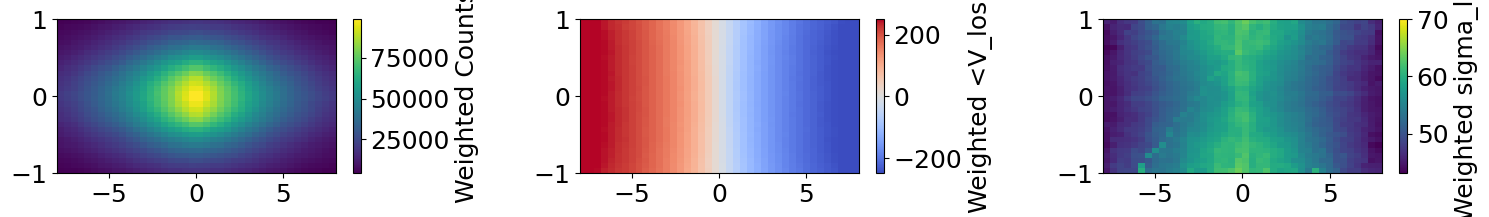

In [37]:

H_weighted, xedge, yedge = np.histogram2d(xv[:,:,0].flatten(), xv[:,:,2].flatten(), bins=(40,30), range=[[-8,8],[-1,1]], weights=weights_stacked)
H_vlos, xedge, yedge = np.histogram2d(xv[:,:,0].flatten(), xv[:,:,2].flatten(), bins=(40,30), range=[[-8,8],[-1,1]], weights=xv[:,:,4].flatten() * weights_stacked)
H_vlos2, xedge, yedge = np.histogram2d(xv[:,:,0].flatten(), xv[:,:,2].flatten(), bins=(40,30), range=[[-8,8],[-1,1]], weights=(xv[:,:,4].flatten()**2) * weights_stacked)
vlos_weighted = H_vlos / (H_weighted + EPSILON)
vlos_std = jnp.sqrt(H_vlos2 / (H_weighted + EPSILON) - vlos_weighted**2)

# weights_stacked.shape

fig1, ax1 = plt.subplots(1, 3, figsize=(18,2), gridspec_kw={'wspace':0.5})
cb = ax1[0].pcolormesh(xedge, yedge, H_weighted.T, cmap='viridis', shading='auto')
fig1.colorbar(cb, ax=ax1[0], label='Weighted Counts')
cb = ax1[1].pcolormesh(xedge, yedge, vlos_weighted.T, cmap='coolwarm', shading='auto', vmin=-250, vmax=250)
fig1.colorbar(cb, ax=ax1[1], label='Weighted <V_los>')
cb = ax1[2].pcolormesh(xedge, yedge, vlos_std.T, cmap='viridis', shading='auto', vmax=70)
fig1.colorbar(cb, ax=ax1[2], label='Weighted sigma_los')

Total counts in XY bins: 1200 and only 1 per bin: True


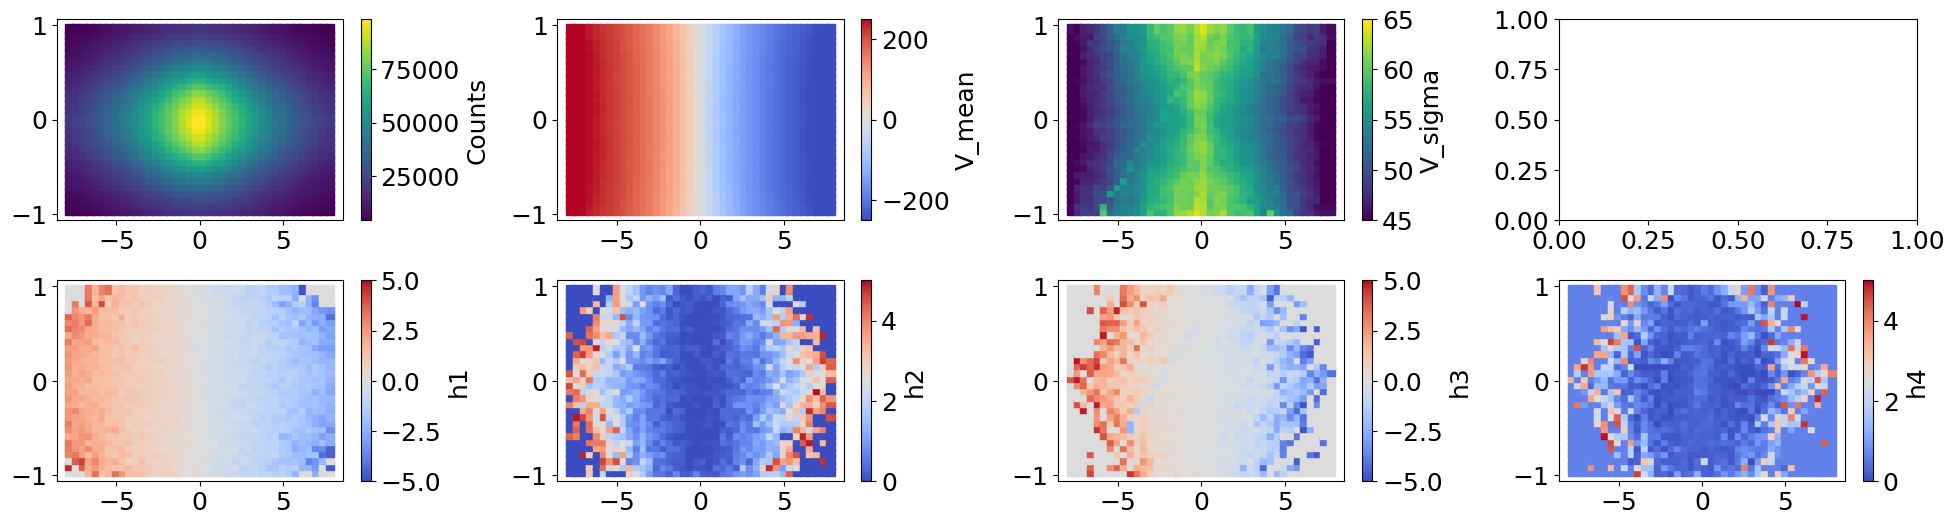

In [47]:
X_min, X_max = -8., 8.
Y_min, Y_max = -1., 1.
nX, nY = 40, 30

X_edge = jnp.linspace(X_min, X_max, nX+1)
Y_edge = jnp.linspace(Y_min, Y_max, nY+1)
X_mids, Y_mids = 0.5 * (X_edge[:-1] + X_edge[1:]), 0.5 * (Y_edge[:-1] + Y_edge[1:])

X_mid_mesh, Y_mids_mesh = jnp.meshgrid(X_mids, Y_mids, indexing='ij')
XY_mid_grid = jnp.stack([X_mid_mesh.ravel(), Y_mids_mesh.ravel()], axis=-1)  # (n_X*n_Y, 2)

XY_minmax=jnp.array([[X_min,X_max],[Y_min,Y_max]])
nXY=jnp.array([nX,nY])
num_segments_XY=nXY.prod()
XY_strides = jnp.concatenate([jnp.array([1]), jnp.cumprod(nXY[:-1])])
XY_grid_indices = assign_regular_grid(XY_mid_grid,
                                    grid_min=XY_minmax[:,0],
                                    grid_max=XY_minmax[:,1],
                                    n_bins=nXY,
                                    strides=XY_strides)
_, COUNTS_XY = jnp.unique(XY_grid_indices, return_counts=True)
print('Total counts in XY bins:', jnp.sum(COUNTS_XY), 'and only 1 per bin:', jnp.all(COUNTS_XY <= 1))

df_XY = pd.DataFrame({
    'id': XY_grid_indices,
    'X_grid': XY_mid_grid[:,0],
    'Y_grid': XY_mid_grid[:,1],
})

XY_stars = jnp.array([
            xv[:,:,0].flatten(), xv[:,:,2].flatten()
            ]).T  # (n_stars, 2)


XY_strdides = jnp.concatenate([jnp.array([1]), jnp.cumprod(nXY[:-1])])
XY_indices = assign_regular_grid(XY_stars,
                                grid_min=XY_minmax[:,0],
                                grid_max=XY_minmax[:,1],
                                n_bins=nXY,
                                strides=XY_strdides)

vy = xv[:,:,4].flatten()
index = jnp.arange(num_segments_XY)
counts = jax.ops.segment_sum(weights_stacked * jnp.ones_like(vy), XY_indices, num_segments=num_segments_XY)
V_mean = jax.ops.segment_sum(weights_stacked * vy, XY_indices, num_segments=num_segments_XY) / (counts + EPSILON)
V2_mean = jax.ops.segment_sum(weights_stacked * vy**2, XY_indices, num_segments=num_segments_XY) / (counts + EPSILON)
V_sigma = jnp.sqrt(jnp.clip(V2_mean - V_mean**2, a_min=0.0))

v0_cell = v0[XY_indices]
s_cell = s[XY_indices]

w = (vy - v0_cell) / s_cell # (v_los - v0) / s, where in edge-on case v_los = vy = wN[:,4]
counts = jax.ops.segment_sum(weights_stacked * jnp.ones_like(vy), XY_indices, num_segments=num_segments_XY)
sum_w1 = jax.ops.segment_sum(weights_stacked * w, XY_indices, num_segments=num_segments_XY)
sum_w2 = jax.ops.segment_sum(weights_stacked * w**2, XY_indices, num_segments=num_segments_XY)
sum_w3 = jax.ops.segment_sum(weights_stacked * w**3, XY_indices, num_segments=num_segments_XY)
sum_w4 = jax.ops.segment_sum(weights_stacked * w**4, XY_indices, num_segments=num_segments_XY)
eps = EPSILON
norm = counts + eps
w1 = sum_w1 / norm
w2 = sum_w2 / norm
w3 = sum_w3 / norm
w4 = sum_w4 / norm

h1 = w1
h2 = ((w2 - 1) / jnp.sqrt(2))
h3 = ((w3 - 3 * w1) / jnp.sqrt(6))
h4 = ((w4 - 6 * w2 + 3) / jnp.sqrt(24))

# N_min = 50
# V_mean = jnp.where(counts < N_min, 0, V_mean)
# V_sigma = jnp.where(counts < N_min, 0, V_sigma)
# h1 = jnp.where(counts < N_min, 0, h1)
# h2 = jnp.where(counts < N_min, -1/jnp.sqrt(2), h2)
# h3 = jnp.where(counts < N_min, 0, h3)
# h4 = jnp.where(counts < N_min, 3/jnp.sqrt(24), h4)
# counts = jnp.where(counts < N_min, 0, counts)
# nonempty_index = counts > N_min #jnp.where(counts > 10)[0]

h1 = jnp.where(jnp.fabs(h1)>5, 0, h1)
h2 = jnp.where(jnp.fabs(h2)>5, -1/jnp.sqrt(2), h2)
h3 = jnp.where(jnp.fabs(h3)>5, 0, h3)
h4 = jnp.where(jnp.fabs(h4)>5, 3/jnp.sqrt(24), h4)

df_XY_moments = pd.DataFrame({
    'id': index,
    'N_count': counts.astype(jnp.float32),
    'V_mean': V_mean,
    'V_sigma': V_sigma,
    'h1': h1,
    'h2': h2,
    'h3': h3,
    'h4': h4,
    'v0_cell': v0,
    's_cell': s,
})
df_XY = df_XY.merge(df_XY_moments, on='id', how='left')

fig2, ax2 = plt.subplots(2,4, figsize=(24,6), gridspec_kw={'wspace':0.4, 'hspace':0.3})
cb = ax2[0,0].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['N_count'], 
                 marker = 's', cmap='viridis', rasterized = True)
fig2.colorbar(cb, ax=ax2[0,0], label='Counts')
cb = ax2[0,1].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['V_mean'], 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin=-250, vmax=250)
fig2.colorbar(cb, ax=ax2[0,1], label='V_mean')
cb = ax2[0,2].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['V_sigma'], 
                 marker = 's', cmap='viridis', rasterized = True, vmin = 45, vmax = 65)
fig2.colorbar(cb, ax=ax2[0,2], label='V_sigma')
cb = ax2[1,0].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['h1'], 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = -5, vmax = 5)
fig2.colorbar(cb, ax=ax2[1,0], label='h1')
cb = ax2[1,1].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['h2'], 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = 0, vmax = 5)
fig2.colorbar(cb, ax=ax2[1,1], label='h2')
cb = ax2[1,2].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['h3'], 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = -5, vmax = 5)
fig2.colorbar(cb, ax=ax2[1,2], label='h3')
cb = ax2[1,3].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['h4'], 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = 0, vmax = 5)
fig2.colorbar(cb, ax=ax2[1,3], label='h4')

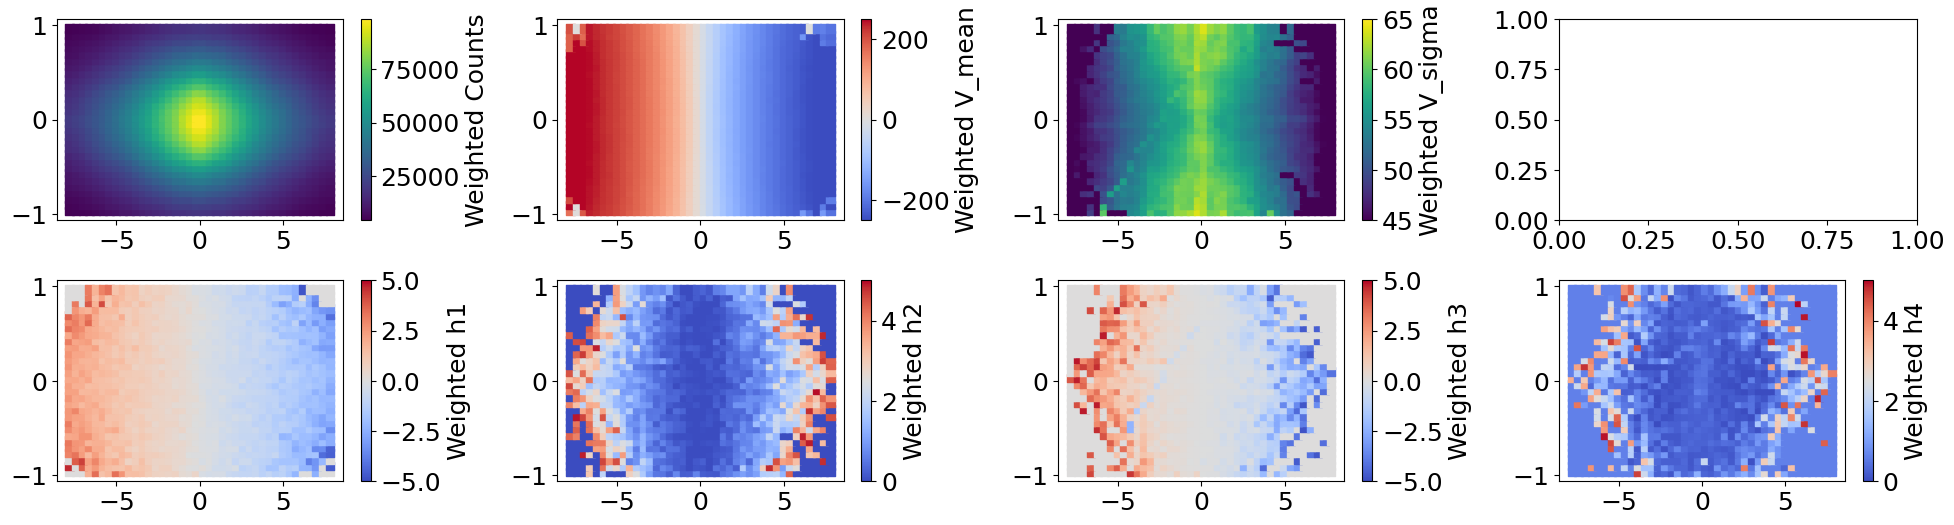

In [48]:
density_2DXY_weighted = 5000 * A_xy @ weights
_A_h1 = A_h1 * A_xy * 5000
_A_h2 = A_h2 * A_xy * 5000
_A_h3 = A_h3 * A_xy * 5000
_A_h4 = A_h4 * A_xy * 5000
h1_model_weighted = (_A_h1 @ weights) / density_2DXY_weighted
h2_model_weighted = (_A_h2 @ weights) / density_2DXY_weighted
h3_model_weighted = (_A_h3 @ weights) / density_2DXY_weighted
h4_model_weighted = (_A_h4 @ weights) / density_2DXY_weighted

h1_model_weighted = jnp.where(jnp.fabs(h1_model_weighted)>5, 0, h1_model_weighted)
h2_model_weighted = jnp.where(jnp.fabs(h2_model_weighted)>5, -1/jnp.sqrt(2), h2_model_weighted)
h3_model_weighted = jnp.where(jnp.fabs(h3_model_weighted)>5, 0, h3_model_weighted)
h4_model_weighted = jnp.where(jnp.fabs(h4_model_weighted)>5, 3/jnp.sqrt(24), h4_model_weighted)

V_model_weighted, sigma_model_weighted = h_to_V_sigma(h1_model_weighted, h2_model_weighted, v0, s)

fig3, ax3 = plt.subplots(2,4, figsize=(24,6), gridspec_kw={'wspace':0.4, 'hspace':0.3})
cb = ax3[0,0].scatter(df_XY_data['X_grid'], df_XY_data['Y_grid'], c=density_2DXY_weighted, 
                 marker = 's', cmap='viridis', rasterized = True)
fig3.colorbar(cb, ax=ax3[0,0], label='Weighted Counts')
cb = ax3[0,1].scatter(df_XY_data['X_grid'], df_XY_data['Y_grid'], c=V_model_weighted, 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin=-250, vmax=250)
fig3.colorbar(cb, ax=ax3[0,1], label='Weighted V_mean')
cb = ax3[0,2].scatter(df_XY_data['X_grid'], df_XY_data['Y_grid'], c=sigma_model_weighted, 
                 marker = 's', cmap='viridis', rasterized = True, vmin = 45, vmax = 65)
fig3.colorbar(cb, ax=ax3[0,2], label='Weighted V_sigma')
cb = ax3[1,0].scatter(df_XY_data['X_grid'], df_XY_data['Y_grid'], c=h1_model_weighted, 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = -5, vmax = 5)
fig3.colorbar(cb, ax=ax3[1,0], label='Weighted h1')
cb = ax3[1,1].scatter(df_XY_data['X_grid'], df_XY_data['Y_grid'], c=h2_model_weighted, 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = 0, vmax = 5)
fig3.colorbar(cb, ax=ax3[1,1], label='Weighted h2')
cb = ax3[1,2].scatter(df_XY_data['X_grid'], df_XY_data['Y_grid'], c=h3_model_weighted, 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = -5, vmax = 5)
fig3.colorbar(cb, ax=ax3[1,2], label='Weighted h3')
cb = ax3[1,3].scatter(df_XY_data['X_grid'], df_XY_data['Y_grid'], c=h4_model_weighted, 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = 0, vmax = 5)
fig3.colorbar(cb, ax=ax3[1,3], label='Weighted h4') 

In [22]:

# @jax.jit
def integrate_voronoi(params_halo_pot, params_disk_rho, dict_data):

    w0 = dict_data['w0']
    n_particles = w0.shape[0]
    v0 = dict_data['v0']
    s = dict_data['s']
    num_per_bin = dict_data['num_per_bin']
    bin_mapping = dict_data['bin_mapping']
    num_Vbin = dict_data['total_bins']
    #=========================================== GET DISC POTENTIAL =====================================================

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    #=========================================== GET INITIAL VELOCITY ===================================================

    get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
    # jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)

    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
    g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    vR = g1 * sig_R
    vz = g2 * sig_z
    vphi = v_rot + g3 * sig_phi

    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)

    w0_new = jnp.array([x, y, w0[:,2], vx, vy, vz]).T

    #=========================================== Integrate orbits =======================================================
    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    Rzphi_bin_counts, surface_density, h1, h2, h3, h4 = jax.vmap(integrate_leapfrog_voronoi, 
                                                     in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None))\
                        (w0_new, acc_fn, n_steps, dt, initial_time, unroll,
                        num_Vbin, bin_mapping, num_per_bin,
                        jnp.array([[0,10.],[-3,3],[-jnp.pi, jnp.pi]]), jnp.array([[-10.,10.],[-3.,3.]]),
                        jnp.array([10,6,6]), jnp.array([60,40]), 360,
                        v0, s)

    # jax.debug.print("h1 shape: {x_norm}", x_norm=h1.shape)
    # jax.debug.print("h1 nan: {x_norm}", x_norm=jnp.isnan(h1).sum())
    # print("h1 shape: {x_norm}",h1.shape)
    # print("h1 nan: {x_norm}",jnp.isnan(h1).sum())
    # print("h1 non zero: {x_norm}",(h1!=0).sum())
    # print("h2 shape: {x_norm}",h2.shape)
    # print("h2 nan: {x_norm}",jnp.isnan(h2).sum())
    # print("h2 non zero: {x_norm}",(h2!=0).sum())
    # print("h3 shape: {x_norm}",h3.shape)
    # print("h3 nan: {x_norm}",jnp.isnan(h3).sum())
    # print("h3 non zero: {x_norm}",(h3!=0).sum())
    # print("h4 shape: {x_norm}",h4.shape)
    # print("h4 nan: {x_norm}",jnp.isnan(h4).sum())
    # print("h4 non zero: {x_norm}",(h4!=0).sum())
    # print("Nxy nan: {x_norm}",jnp.isnan(Nxy).sum())
    # print("Nxy non zero: {x_norm}",(Nxy!=0).sum())
    #=========================================== Orbital weights optimisation ============================================
    A_Rzphi = Rzphi_bin_counts.T / n_steps
    A_xy = surface_density.T / n_steps
    A_h1 = h1.T
    A_h2 = h2.T
    A_h3 = h3.T
    A_h4 = h4.T

    return A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s


In [32]:
df_ic = pd.read_csv(path + 'mock_initial_conditions_xyz.csv')
df_ic = df_ic[np.sqrt(df_ic['x']**2 + df_ic['y']**2) < 10.0]
df_ic = df_ic[np.fabs(df_ic['z']) < 3.0]

n_particles =  10_000

print(n_particles)
np.random.seed(42)
index = np.random.choice(len(df_ic['x']), size=n_particles, replace=False)
df_ic = df_ic.iloc[index]
# w0 = jnp.array([df_ic['x'], df_ic['y'], df_ic['z'], df_ic['vx'], df_ic['vy'], df_ic['vz']]).T
w0 = jnp.array(df_ic[['x','y','z']].to_numpy())


with open(path + 'mock_axisymmetric_disc_XY_voronoi.pkl', 'rb') as f:
    bin_dict = pickle.load(f)

# regular grid parameters
nX, nY = bin_dict['nX_nY']
X_min, X_max = bin_dict['X_minmax']
Y_min, Y_max = bin_dict['Y_minmax']
X_regular_grid = bin_dict['X_regular_grid']
Y_regular_grid = bin_dict['Y_regular_grid']

# voronoi binning mapping and data
xy_vbins = bin_dict['voronoi_bins_xy']
num_per_bin = jnp.array(bin_dict['num_per_bin'])
total_bins = jnp.array(bin_dict['total_bins'])
bin_mapping = jnp.array(bin_dict['bin_mapping'])
surface_density = jnp.array(bin_dict['surface_density'])
V_data = jnp.array(bin_dict['V_mean'])
sigma_data = jnp.array(bin_dict['V_sigma'])
h1_data = jnp.array(bin_dict['h1'])
h2_data = jnp.array(bin_dict['h2'])
h3_data = jnp.array(bin_dict['h3'])
h4_data = jnp.array(bin_dict['h4'])
v0 = jnp.array(bin_dict['v0'])
s = jnp.array(bin_dict['s'])

V_data_err = jnp.where(0.1 * jnp.fabs(V_data) < 10, 10, 0.1 * V_data)
sigma_data_err = jnp.where(0.1 * jnp.fabs(sigma_data) < 5, 5, 0.1 * sigma_data)
h1_data_err = jnp.where(0.1 * jnp.fabs(h1_data) < 0.01, 0.01, 0.1 * jnp.fabs(h1_data))
h2_data_err = jnp.where(0.1 * jnp.fabs(h2_data) < 0.01, 0.01, 0.1 * jnp.fabs(h2_data))
h3_data_err = jnp.where(0.1 * jnp.fabs(h3_data) < 0.01, 0.01, 0.1 * jnp.fabs(h3_data))
h4_data_err = jnp.where(0.1 * jnp.fabs(h4_data) < 0.01, 0.01, 0.1 * jnp.fabs(h4_data))

# df_Rzphi_data = pd.read_csv(path + 'axisymmetric_disc_Rzphi.csv')
# Rzphi_density_data = jnp.array(df_Rzphi_data['mass'].to_numpy()).astype(jnp.float32)


dict_data = {
    'w0': w0,
    'v0': v0,
    's': s,
    # 'Rzphi_density_data': Rzphi_density_data,
    'XY_density_data': surface_density,
    'V_data': V_data,
    'V_data_err': V_data_err,
    'sigma_data': sigma_data,
    'sigma_data_err': sigma_data_err,
    'h1_data': h1_data,
    'h1_data_err': h1_data_err,
    'h2_data': h2_data,
    'h2_data_err': h2_data_err,
    'h3_data': h3_data,
    'h3_data_err': h3_data_err,
    'h4_data': h4_data,
    'h4_data_err': h4_data_err,
    'num_per_bin': num_per_bin,
    'bin_mapping': bin_mapping,
    'total_bins': total_bins.item()
}


with open(path + '/mock_axisymmetric_disc_potential_params.pkl', 'rb') as f:
    gt_params = pickle.load(f)

N = 20
i = 11
ground_truth = {
        'logM_halo': gt_params['halo_params']['logM'].item() + (i-N/2)/10,
        'logRs_halo': jnp.log10(gt_params['halo_params']['scaleRadius']).item(),
        'logM_disk': gt_params['disc_params']['logM'].item(),
        'logRs_disk': jnp.log10(gt_params['disc_params']['scaleRadius']).item(),
        'logHs_disk': jnp.log10(gt_params['disc_params']['scaleHeight']).item(),
}
# ground_truth = {
#         'logM_halo': jnp.log10(0.8*10**12).item() + (i-N/2)/10,
#         'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
#         'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
#         'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
#         'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
# }

params_halo_pot = {
    'logM': ground_truth['logM_halo'],
    'Rs':10 ** ground_truth['logRs_halo'],
    'a':1.0,
    'b':1.0,
    'c':1.0,
    'x_origin':0.0,
    'y_origin':0.0,
    'z_origin':0.0,
    'dirx':0.0,
    'diry':0.0,
    'dirz':1.0
}

params_disk_rho = {
    'logM': ground_truth['logM_disk'],
    'Rs': 10 ** ground_truth['logRs_disk'],
    'Hs': 10 ** ground_truth['logHs_disk'],
    'x_origin': 0.0,
    'y_origin': 0.0,
    'z_origin': 0.0,
    'dirx': 0.0,
    'diry': 0.0,
    'dirz': 1.0
}

# logL, V_model, sigma_model, h3_model, h4_model = logl(ground_truth, dict_data)
A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s = integrate_voronoi(
    params_halo_pot,
    params_disk_rho,
    dict_data
)

# time, xv = integrate_without_binning(
#     params_halo_pot,
#     params_disk_rho,
#     dict_data
# )

# weights = jnp.array(np.random.uniform(0.5, 1.5, size=xv.shape[0]))
weights = jnp.array(np.random.uniform(0.99, 1.01, size=A_xy.shape[1]))
weights_stacked = jnp.repeat(weights[:, jnp.newaxis], A_xy.shape[1], axis=1)
weights_stacked = weights_stacked.flatten()

A_Rzphi.block_until_ready()

10000


Array([[0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
       [0.0036, 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
       [0.013 , 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
       ...,
       [0.    , 0.0026, 0.    , ..., 0.    , 0.    , 0.    ],
       [0.    , 0.0016, 0.    , ..., 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ]],      dtype=float32)

In [6]:
A_xy.shape

(1055, 10000)

In [113]:
total_bins

Array(1055, dtype=int32)

In [120]:
bin_mapping.shape

(2401,)

<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:46: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:46: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3542972/159803802.py:45: SyntaxWarning: invalid escape sequence '\s'
  fig1.colorbar(cb3, ax=ax1[0,2], label='$\sigma_V$ [km/s]')
/tmp/ipykernel_3542972/159803802.py:46: SyntaxWarning: invalid escape sequence '\s'
  ax1[0,2].set_title('$\sigma_V$')


Text(0, 0.5, 'Y [kpc]')

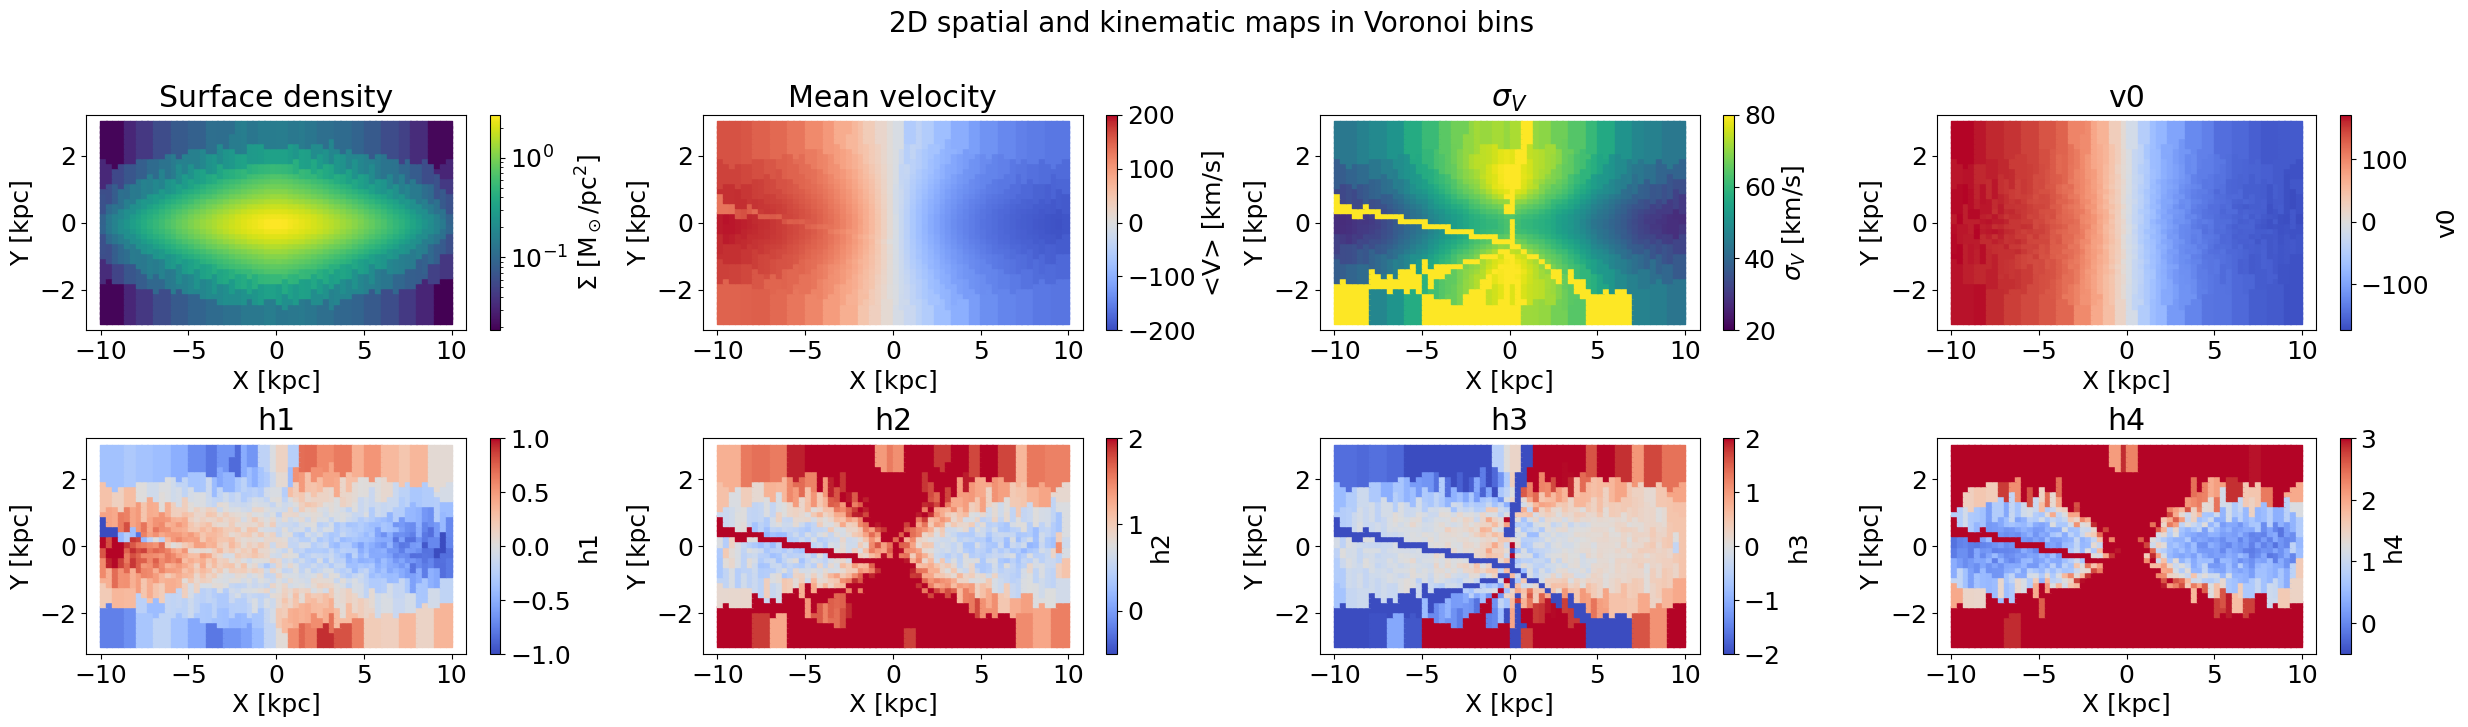

In [33]:
_A_xy = A_xy * 5000
density_2DXY_weighted = _A_xy @ weights
_A_h1 = A_h1 * _A_xy
_A_h2 = A_h2 * _A_xy
_A_h3 = A_h3 * _A_xy
_A_h4 = A_h4 * _A_xy
h1_model_weighted = (_A_h1 @ weights) / density_2DXY_weighted
h2_model_weighted = (_A_h2 @ weights) / density_2DXY_weighted
h3_model_weighted = (_A_h3 @ weights) / density_2DXY_weighted
h4_model_weighted = (_A_h4 @ weights) / density_2DXY_weighted

# h1_model_weighted = jnp.where(jnp.fabs(h1_model_weighted)>5, 0, h1_model_weighted)
# h2_model_weighted = jnp.where(jnp.fabs(h2_model_weighted)>5, -1/jnp.sqrt(2), h2_model_weighted)
# h3_model_weighted = jnp.where(jnp.fabs(h3_model_weighted)>5, 0, h3_model_weighted)
# h4_model_weighted = jnp.where(jnp.fabs(h4_model_weighted)>5, 3/jnp.sqrt(24), h4_model_weighted)

V_model_weighted, sigma_model_weighted = h_to_V_sigma(h1_model_weighted, h2_model_weighted, v0, s)

index_remap = bin_mapping[:-1]

density_2DXY_weighted = density_2DXY_weighted[index_remap]
V_model_weighted = V_model_weighted[index_remap]
sigma_model_weighted = sigma_model_weighted[index_remap]
h1_model_weighted = h1_model_weighted[index_remap]
h2_model_weighted = h2_model_weighted[index_remap]
h3_model_weighted = h3_model_weighted[index_remap]
h4_model_weighted = h4_model_weighted[index_remap]

fig1,ax1 = plt.subplots(2,4,figsize=(30,7), gridspec_kw={'hspace':0.5, 'wspace':0.3})
fig1.suptitle('2D spatial and kinematic maps in Voronoi bins', fontsize=20, y = 1.03)
cb1 = ax1[0,0].scatter(X_regular_grid, Y_regular_grid, c=density_2DXY_weighted, 
                s = 20, cmap='viridis', marker = 's', norm = 'log')
fig1.colorbar(cb1, ax=ax1[0,0], label=r'$\Sigma$ [M$_\odot$/pc$^2$]')
ax1[0,0].set_title('Surface density')
ax1[0,0].set_xlabel('X [kpc]')
ax1[0,0].set_ylabel('Y [kpc]')
cb2 = ax1[0,1].scatter(X_regular_grid, Y_regular_grid, c=V_model_weighted, 
                s = 20, cmap='coolwarm', marker = 's', vmin = -200, vmax=200)
fig1.colorbar(cb2, ax=ax1[0,1], label='<V> [km/s]')
ax1[0,1].set_title('Mean velocity')
ax1[0,1].set_xlabel('X [kpc]')
ax1[0,1].set_ylabel('Y [kpc]')
cb3 = ax1[0,2].scatter(X_regular_grid, Y_regular_grid, c=sigma_model_weighted, 
                s = 20, cmap='viridis', marker = 's', vmin = 20, vmax=80)
fig1.colorbar(cb3, ax=ax1[0,2], label='$\sigma_V$ [km/s]')
ax1[0,2].set_title('$\sigma_V$')
ax1[0,2].set_xlabel('X [kpc]')
ax1[0,2].set_ylabel('Y [kpc]')

cb4 = ax1[1,0].scatter(X_regular_grid, Y_regular_grid, c=h1_model_weighted,
                s = 20, cmap='coolwarm', marker = 's', vmin = -1, vmax=1)
fig1.colorbar(cb4, ax=ax1[1,0], label='h1')
ax1[1,0].set_title('h1')
ax1[1,0].set_xlabel('X [kpc]')
ax1[1,0].set_ylabel('Y [kpc]')
cb5 = ax1[1,1].scatter(X_regular_grid, Y_regular_grid, c=h2_model_weighted,
                s = 20, cmap='coolwarm', marker = 's', vmin = -0.5, vmax=2)
fig1.colorbar(cb5, ax=ax1[1,1], label='h2')
ax1[1,1].set_title('h2')
ax1[1,1].set_xlabel('X [kpc]')
ax1[1,1].set_ylabel('Y [kpc]')
cb6 = ax1[1,2].scatter(X_regular_grid, Y_regular_grid, c=h3_model_weighted,
                s = 20, cmap='coolwarm', marker = 's', vmin = -2, vmax=2)
fig1.colorbar(cb6, ax=ax1[1,2], label='h3')
ax1[1,2].set_title('h3')
ax1[1,2].set_xlabel('X [kpc]')
ax1[1,2].set_ylabel('Y [kpc]')
cb7 = ax1[1,3].scatter(X_regular_grid, Y_regular_grid, c=h4_model_weighted,
                s = 20, cmap='coolwarm', marker = 's', vmin = -0.5, vmax=3)
fig1.colorbar(cb7, ax=ax1[1,3], label='h4')
ax1[1,3].set_title('h4')
ax1[1,3].set_xlabel('X [kpc]')
ax1[1,3].set_ylabel('Y [kpc]')

cb7 = ax1[0,3].scatter(X_regular_grid, Y_regular_grid, c=v0[index_remap],
                s = 20, cmap='coolwarm', marker = 's')
fig1.colorbar(cb7, ax=ax1[0,3], label='v0')
ax1[0,3].set_title('v0')
ax1[0,3].set_xlabel('X [kpc]')
ax1[0,3].set_ylabel('Y [kpc]')

In [85]:
V_model_weighted

Array([ 129.38826,  129.38826,  126.79983, ..., -125.5011 , -129.94327,
       -129.94327], dtype=float32)